In [2]:
import scipy.linalg as lg
import numpy as np

In [3]:
# a) Define a matrix

A = np.array([
    [1, -2, 3],
    [4, 5, 6],
    [7, 1, 9]
])

print(A)


[[ 1 -2  3]
 [ 4  5  6]
 [ 7  1  9]]


In [4]:
# b) Define a vector b

b = np.array([1, 2, 3])

print(b)

[1 2 3]


In [5]:
# c) Solve the linear system of equations A x = b (solve the normal equations)

AT = np.transpose(A)
ATA = np.matmul(AT, A)
ATb = np.matmul(AT, b)

x = np.linalg.solve(ATA, ATb)
print(x)


[-2.65026519e-15  1.22568622e-16  3.33333333e-01]


In [6]:
# d) Check that your solution is correct by plugging it into the equation

if np.allclose(np.matmul(A, x), b):
    print("True")
else:
    print("False")


True


In [7]:
# e) Repeat steps a-d using a random 3x3 matrix B (instead of the vector b)

# From normal distr 
B = np.random.randn(3, 3)

# Solve 
ATB = np.matmul(AT, B)
x = np.linalg.solve(ATA, ATB)
print(x)

# Check solution
if np.allclose(np.matmul(A, x), B):
    print("True")
else:
    print("False")




[[-0.95129739 -0.77697383  0.05251457]
 [-0.25580844  0.10502518  0.08229628]
 [ 0.83090626  0.37319742 -0.08544391]]
True


In [8]:
# f) Solve the eigenvalue problem for the matrix A and print the eigenvalues and eigenvectors

# Eigenvalues and eigenvectors
eigvals, eigvecs = lg.eig(A)

print("Eigenvalues: \n")
print(eigvals)

print("\nEigenvectors (columns): \n")
print(eigvecs)

Eigenvalues: 

[-1.13261772+0.j 10.67269524+0.j  5.45992248+0.j]

Eigenvectors (columns): 

[[-0.8215735   0.05324273  0.25636602]
 [-0.02150583  0.74309552 -0.93563185]
 [ 0.56969684  0.66706391 -0.24263037]]


In [10]:
# g) Calculate the inverse, determinant of A

A_inv = lg.inv(A)
A_det = lg.det(A)

print("Inverse of A: \n")
print(A_inv)

print("Determinant of A: \n")
print(A_det)

Inverse of A: 

[[-0.59090909 -0.31818182  0.40909091]
 [-0.09090909  0.18181818 -0.09090909]
 [ 0.46969697  0.22727273 -0.1969697 ]]
Determinant of A: 

-66.0


In [12]:
# h) Calculate the norm of A with different orders

# Norms of A
print("Norms of A: \n")
print("Default norm: ", lg.norm(A))    
print("1-norm: ", lg.norm(A, 1))
print("2-norm: ", lg.norm(A, 2))

Norms of A: 

Default norm:  14.89966442575134
1-norm:  18.0
2-norm:  14.173659390884978


Statistics

In [15]:
from scipy import stats
import matplotlib.pyplot as plt

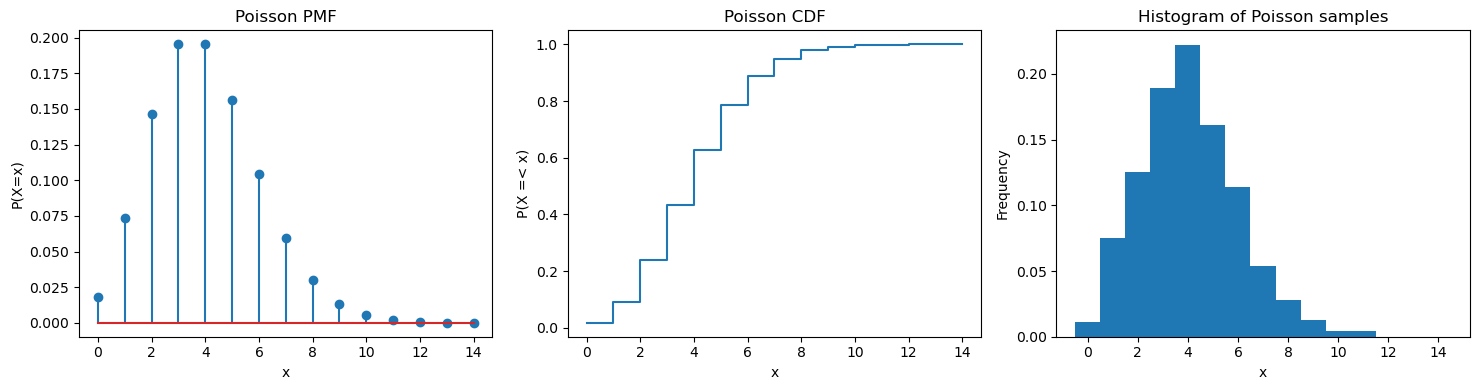

In [19]:
# a) Discrete random variable: Poisson distribution

l = 4
poisson_dist = stats.poisson(mu=l)

x_vals = np.arange(0, 15)
poisson_samples = poisson_dist.rvs(size=1000)

plt.figure(figsize=(15, 4))

plt.subplot(1, 3, 1)
plt.stem(x_vals, poisson_dist.pmf(x_vals))
plt.title("Poisson PMF")
plt.xlabel("x")
plt.ylabel("P(X=x)")

plt.subplot(1, 3, 2)
plt.step(x_vals, poisson_dist.cdf(x_vals), where='post')
plt.title("Poisson CDF")
plt.xlabel("x")
plt.ylabel("P(X =< x)")

plt.subplot(1, 3, 3)
plt.hist(poisson_samples, bins=np.arange(-0.5, 15.5, 1), density=True)
plt.title("Histogram of Poisson samples")
plt.xlabel("x")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

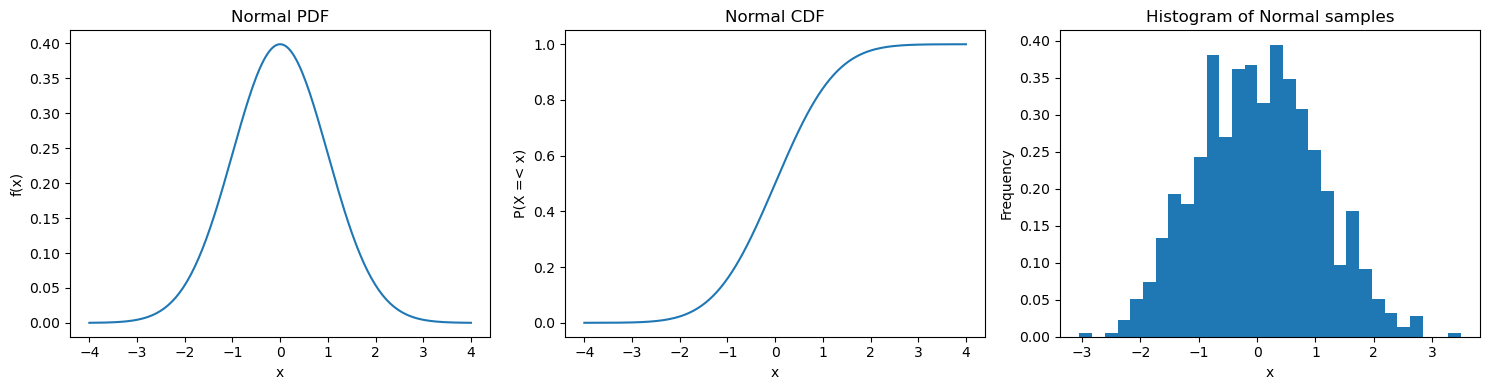

In [20]:
# b) Continuous random variable: Normal distribution

mu = 0
sigma = 1
normal_dist = stats.norm(loc=mu, scale=sigma)

x_vals = np.linspace(-4, 4, 200)
normal_samples = normal_dist.rvs(size=1000)

plt.figure(figsize=(15, 4))

plt.subplot(1, 3, 1)
plt.plot(x_vals, normal_dist.pdf(x_vals))
plt.title("Normal PDF")
plt.xlabel("x")
plt.ylabel("f(x)")

plt.subplot(1, 3, 2)
plt.plot(x_vals, normal_dist.cdf(x_vals))
plt.title("Normal CDF")
plt.xlabel("x")
plt.ylabel("P(X =< x)")

plt.subplot(1, 3, 3)
plt.hist(normal_samples, bins=30, density=True)
plt.title("Histogram of Normal samples")
plt.xlabel("x")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

In [35]:

# c) Test if two independent datasets come from the same distribution

data1 = np.random.normal(loc=0, scale=1, size=100)
data2 = np.random.normal(loc=0, scale=1, size=100)

t_stat, p_value = stats.ttest_ind(data1, data2)

print("Independent t-test: \n")
print("t-statistic =", t_stat)
print("p-value =", p_value)

if p_value < 0.05:
    print("Reject null hypothesis: the means differ significantly")
else:
    print("Fail to reject null hypothesis: no significant difference in means")

Independent t-test: 

t-statistic = 0.37210750748618726
p-value = 0.7102107558302142
Fail to reject null hypothesis: no significant difference in means
